In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [10]:
local_img_path = 'appl.jpg'

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

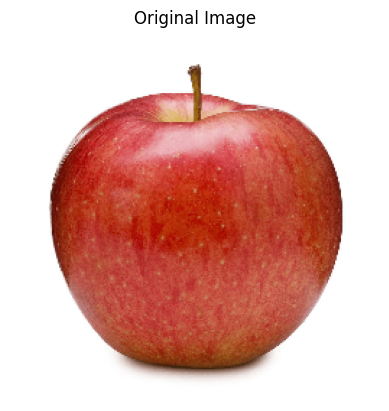

In [11]:
img = cv2.imread(local_img_path)
img = cv2.resize(img, (256, 256))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")


In [12]:
def create_fruit_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # White background mask
    lower = np.array([0, 0, 0])
    upper = np.array([180, 255, 240])

    mask = cv2.inRange(hsv, lower, upper)
    mask = cv2.bitwise_not(mask)

    # Clean mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask


In [ ]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Choose largest contour (fruit)
cnt = max(contours, key=cv2.contourArea)

# Visualize contour
contour_img = img.copy()
cv2.drawContours(contour_img, [cnt], -1, (0,255,0), 2)

plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Fruit Contour")
plt.axis("off")

NameError: name 'mask' is not defined

In [14]:
def compute_shape_features(cnt):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h if h != 0 else 0

    rect_area = w * h
    extent = area / rect_area if rect_area > 0 else 0

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    equiv_diameter = np.sqrt(4 * area / np.pi) if area > 0 else 0

    return {
        "Aspect Ratio": aspect_ratio,
        "Extent": extent,
        "Solidity": solidity,
        "Circularity": circularity,
        "Equivalent Diameter": equiv_diameter,
        "Perimeter": perimeter
    }


In [15]:
features = compute_shape_features(cnt)

for k, v in features.items():
    print(f"{k}: {v:.4f}")
plt.show()

NameError: name 'cnt' is not defined

In [ ]:
def create_fruit_mask(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # White background threshold
    lower = np.array([0, 0, 0])
    upper = np.array([180, 255, 240])

    mask = cv2.inRange(hsv, lower, upper)
    mask = cv2.bitwise_not(mask)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return mask

In [ ]:
def extract_shape_features(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return np.zeros(6, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h     if h != 0 else 0

    rect_area = w * h
    extent = area / rect_area        if rect_area > 0 else 0

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area         if hull_area > 0 else 0

    circularity = (4 * np.pi * area) / (perimeter ** 2)     if perimeter > 0 else 0

    equiv_diameter = np.sqrt(4 * area / np.pi)          if area > 0 else 0

    return np.array([aspect_ratio, extent, solidity, circularity, equiv_diameter, perimeter], dtype=np.float32)
